In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#loading dataset
df = pd.read_csv("/content/retail_sales_dataset.csv")
print(df.head())

   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


In [ ]:
#loading and cleaning
df.info()
df.isnull().sum()
df.describe()
df.drop_duplicates(inplace=True)
df['Date'] = pd.to_datetime(df['Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [ ]:
#Descriptive statistics
Mean = df['Total Amount'].mean()
print("Mean Sales : ", Mean)

Median = df['Total Amount'].median()
print("Median Sales : ", Median)

Mode = df['Total Amount'].mode()
print("Mode Sales : ", Mode)

Std = df['Total Amount'].std()
print("Standard Deviation : ", Std)

Mean Sales :  456.0
Median Sales :  135.0
Mode Sales :  0    50
Name: Total Amount, dtype: int64
Standard Deviation :  559.997631555123


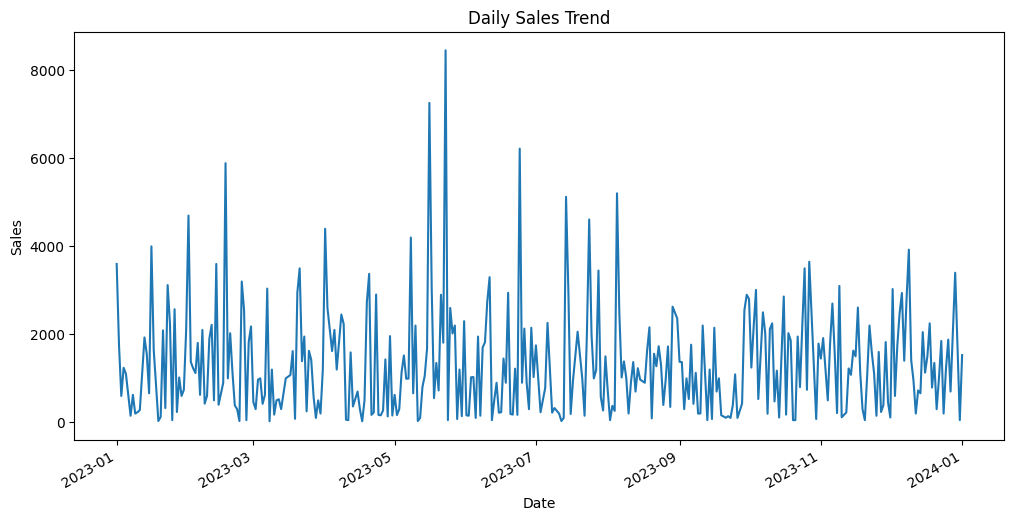

In [ ]:
#Time series analysis
#Daily sales trend
daily_sales = df.groupby('Date')['Total Amount'].sum()

plt.figure(figsize=(12,6))
daily_sales.plot()
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

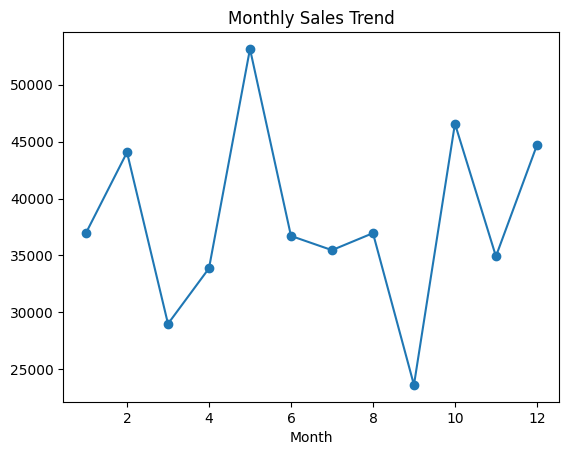

In [ ]:
#monthly sales trend
df['Month'] = df['Date'].dt.month

monthly_sales = df.groupby('Month')['Total Amount'].sum()

monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Sales Trend')
plt.show()

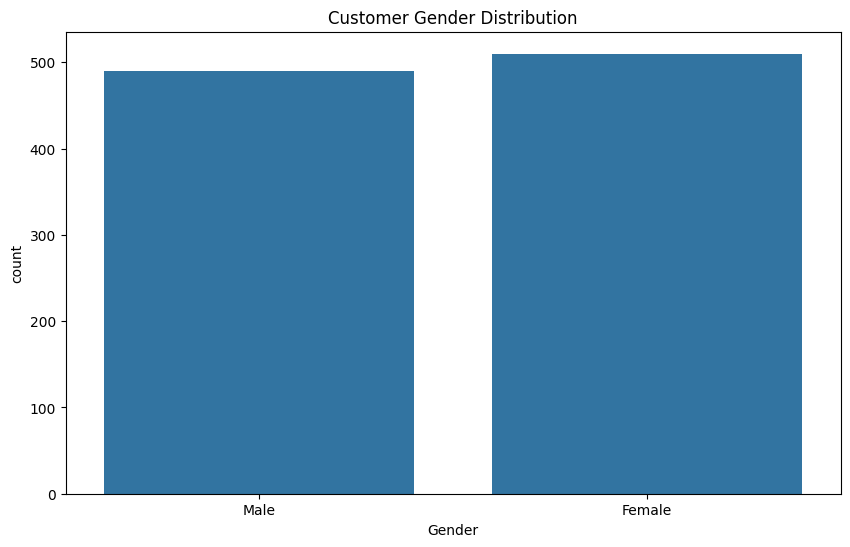

In [ ]:
#Customer analysis
plt.figure(figsize=(10,6))
sns.countplot(x='Gender', data=df)
plt.title('Customer Gender Distribution')
plt.show()

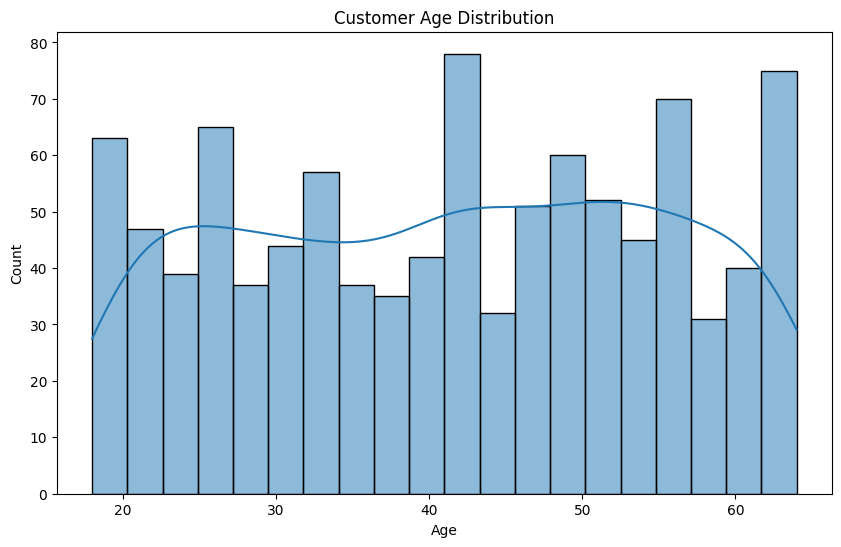

In [ ]:
plt.figure(figsize=(10,6))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title('Customer Age Distribution')
plt.show()

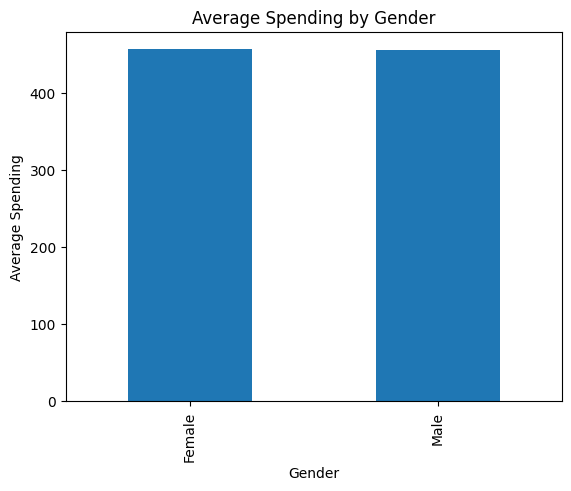

In [ ]:
gender_sales = df.groupby('Gender')['Total Amount'].mean()
gender_sales.plot(kind='bar')
plt.title("Average Spending by Gender")
plt.ylabel("Average Spending")
plt.show()

Product Category
Beauty         143515
Clothing       155580
Electronics    156905
Name: Total Amount, dtype: int64


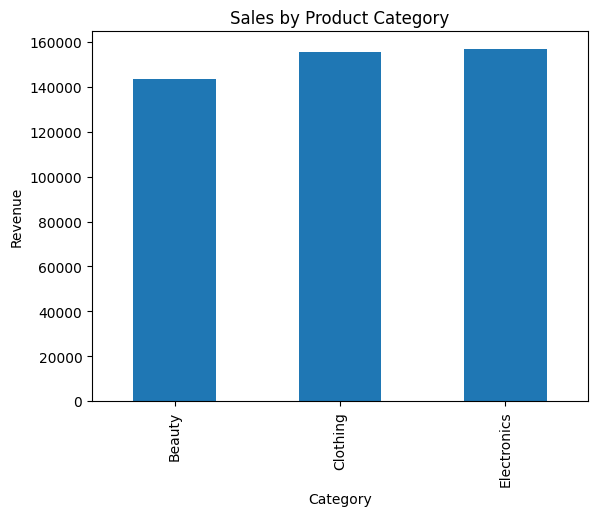

In [ ]:
#product analysis
category_sales = df.groupby('Product Category')['Total Amount'].sum()
print(category_sales)
category_sales.plot(kind='bar')
plt.title("Sales by Product Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

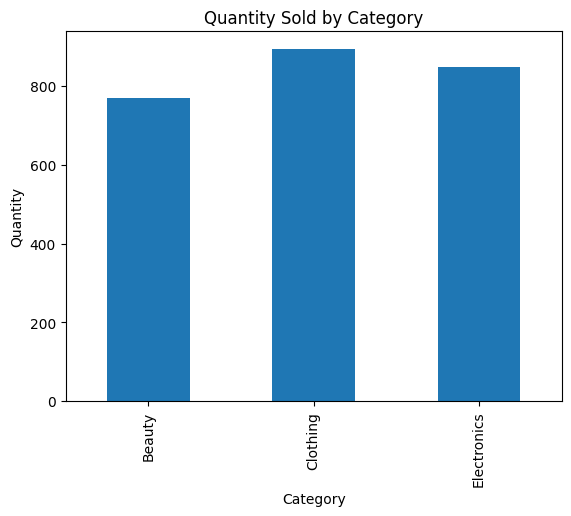

In [ ]:
quantity_sold = df.groupby('Product Category')['Quantity'].sum()
quantity_sold.plot(kind='bar')
plt.title("Quantity Sold by Category")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.show()

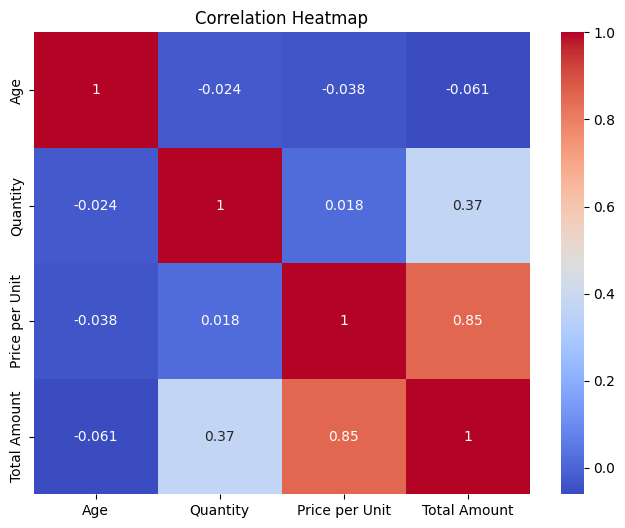

In [ ]:
correlation = df[['Age','Quantity','Price per Unit','Total Amount']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Total Revenue:", df['Total Amount'].sum())
print("Top Product Category:")
print(df.groupby('Product Category')['Total Amount'].sum().idxmax())
print("Average Customer Age:", round(df['Age'].mean(),2))
print("Most Common Gender:", df['Gender'].mode()[0])

Total Revenue: 456000
Top Product Category:
Electronics
Average Customer Age: 41.39
Most Common Gender: Female


In [ ]:
# Recommendations

## 1. Focus on High-Revenue Categories
##Increase inventory and marketing efforts for the top-performing product categories.

## 2. Target Key Customer Segments
##Design personalized offers for the age groups and customer demographics contributing the most sales.

## 3. Plan Seasonal Promotions
##Use monthly sales trends to identify peak and low-demand periods and schedule promotions accordingly.

## 4. Improve Customer Retention
##Introduce loyalty programs and reward schemes for repeat customers.

## 5. Optimize Inventory Management
##Stock products based on demand patterns identified during the analysis.

## 6. Boost Low-Performing Categories
##Offer discounts, bundles, or targeted advertising for categories with lower sales.